In [29]:
import pandas as pd

In [30]:
bike_train=pd.read_csv('bike-train.csv')
bike_train

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [31]:
bike_test=pd.read_csv('bike-test.csv')
bike_test

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


In [32]:
def parse(df):
    date=pd.to_datetime(df['datetime'])
    df['year']=date.dt.year
    df['month']=date.dt.month
    df['day']=date.dt.day
    df['hour']=date.dt.hour
    df['weekday']=date.dt.weekday
    df=df.drop(columns=['datetime'])
    return df

In [33]:
bike_test=parse(bike_test)
bike_test

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,weekday
0,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,0,3
1,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,1,3
2,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,2,3
3,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3
4,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,19,0
6489,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,20,0
6490,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,21,0
6491,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,22,0


In [34]:
bike_train=parse(bike_train)
bike_train

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday
0,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,1,1,0,5
1,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1,1,1,5
2,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,1,1,2,5
3,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,1,1,3,5
4,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,1,1,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,19,2
10882,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,20,2
10883,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21,2
10884,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22,2


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

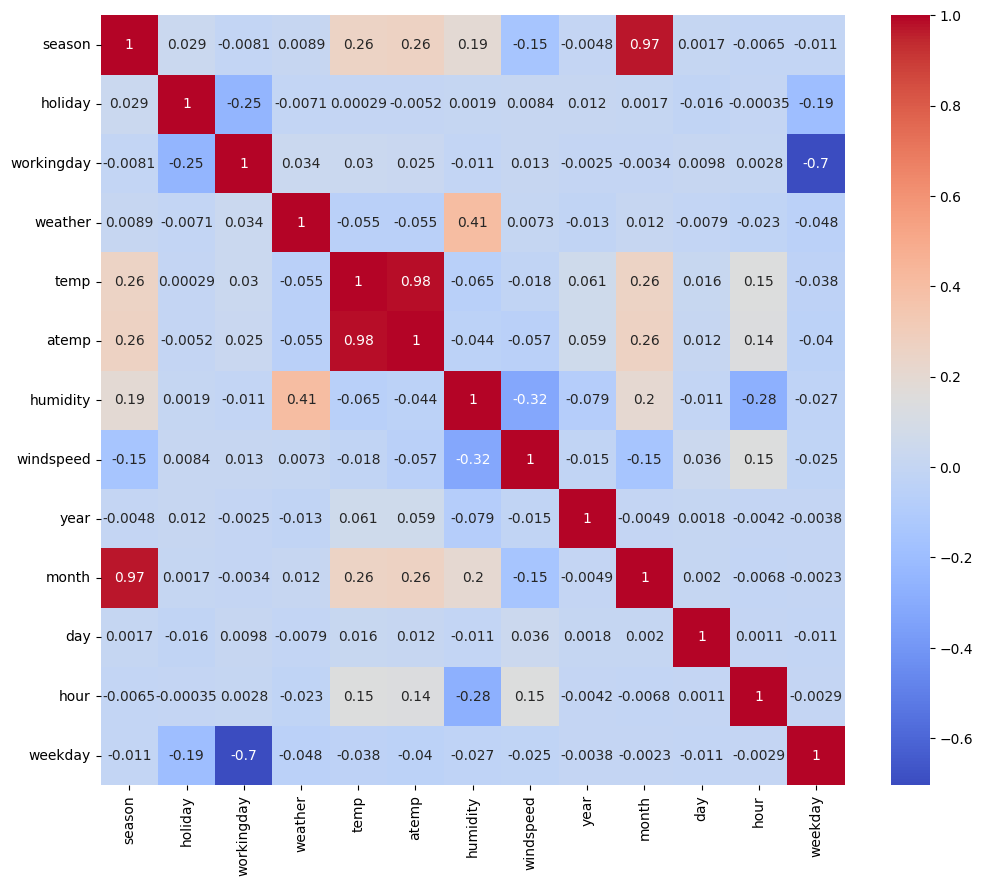

In [36]:
plt.figure(figsize=(12,10))
sns.heatmap(bike_train.drop(columns=['casual','registered','count']).corr(),cmap='coolwarm',annot=True)

In [37]:
x_train=bike_train.drop(columns=['temp','count','month','registered','casual'])
x_test=bike_test.drop(columns=['temp','month'])

In [38]:
x_train['rush_hour']=x_train['hour'].map(lambda x:1 if (x>=7 and x<=9)or(x>=17 and x<=19) else 0)
x_test['rush_hour']=x_test['hour'].map(lambda x:1 if (x>=7 and x<=9)or(x>=17 and x<=19) else 0)

In [39]:
x_train['weekend']=x_train['weekday'].map(lambda x:1 if(x>=5) else 0)
x_test['weekend']=x_test['weekday'].map(lambda x:1 if(x>=5) else 0)

<Axes: >

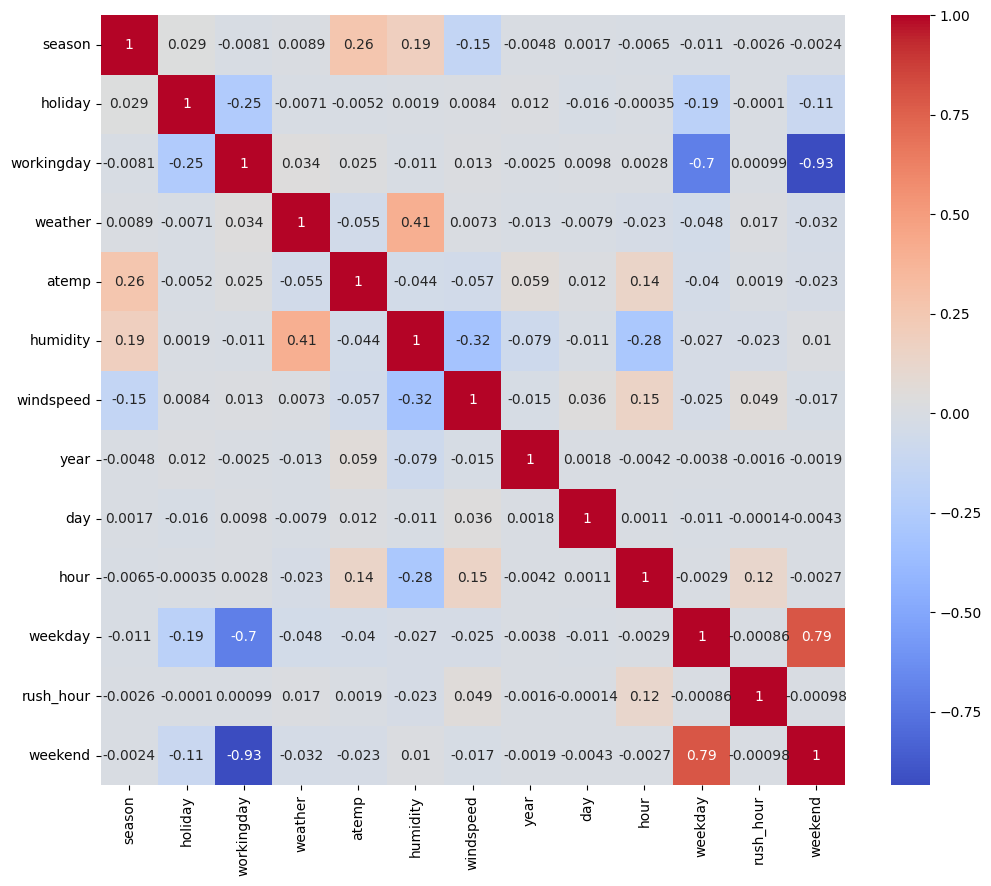

In [40]:
plt.figure(figsize=(12,10))
sns.heatmap(x_train.corr(),cmap='coolwarm',annot=True)

In [41]:
y_train=bike_train['count']
y_train

0         16
1         40
2         32
3         13
4          1
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: count, Length: 10886, dtype: int64

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
model=RandomForestRegressor(n_estimators=300)
model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=300)

In [49]:
y_pred=model.predict(x_test)
y_pred=y_pred.astype('int')

In [50]:
df=pd.read_csv('sampleSubmission.csv')
df

,datetime,count
0,2011-01-20 00:00:00,0
1,2011-01-20 01:00:00,0
2,2011-01-20 02:00:00,0
3,2011-01-20 03:00:00,0
4,2011-01-20 04:00:00,0
...,...,...
6488,2012-12-31 19:00:00,0
6489,2012-12-31 20:00:00,0
6490,2012-12-31 21:00:00,0
6491,2012-12-31 22:00:00,0


In [51]:
df['count']=y_pred
df

,datetime,count
0,2011-01-20 00:00:00,15
1,2011-01-20 01:00:00,6
2,2011-01-20 02:00:00,5
3,2011-01-20 03:00:00,3
4,2011-01-20 04:00:00,3
...,...,...
6488,2012-12-31 19:00:00,228
6489,2012-12-31 20:00:00,136
6490,2012-12-31 21:00:00,97
6491,2012-12-31 22:00:00,98


In [53]:
df.to_csv('submission.csv',encoding='utf-8-sig',index=False)